<a href="https://colab.research.google.com/github/gyuhyeongkim412-creator/financial-data-bootcamp/blob/main/adaboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## 1. 학습 목표
- AdaBoost(Adaptive Boosting) 알고리즘의 원리와 작동 방식 이해
- 약한 학습기(Weak Learner)의 개념과 강한 학습기로의 변환 과정 학습
- 가중치 업데이트 메커니즘과 오차율 계산 방법 이해
- scikit-learn을 활용한 AdaBoost 구현 및 최적화

## 2. 핵심 개념 및 이론

### 2.1 AdaBoost란?
AdaBoost는 여러 개의 약한 학습기를 순차적으로 결합하여 강한 학습기를 만드는 부스팅 알고리즘입니다.

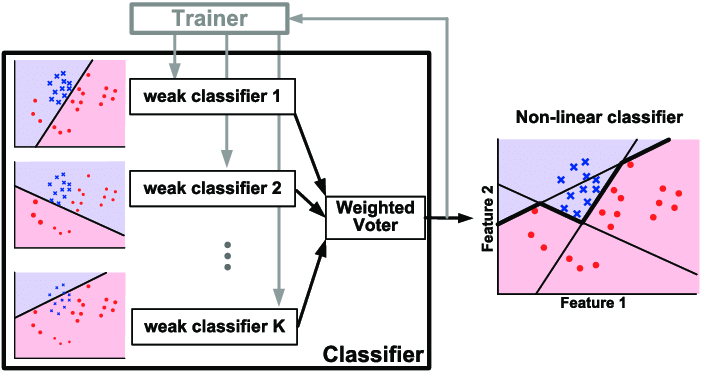

**핵심 아이디어:**
- 약한 학습기들을 순차적으로 학습
- 이전 학습기가 틀린 샘플에 더 높은 가중치 부여
- 각 학습기의 성능에 따라 최종 투표 가중치 결정
- 적응적으로(Adaptive) 오류를 수정해 나가는 과정

### 2.2 약한 학습기 (Weak Learner)
- 랜덤 추측보다는 약간 나은 성능 (정확도 > 50%)
- 일반적으로 깊이 1인 결정 트리(Decision Stump) 사용
- 단순하여 빠른 학습이 가능
- 높은 편향, 낮은 분산 특성

### 2.3 AdaBoost의 작동 원리
1. 모든 샘플에 동일한 가중치 할당
2. 약한 학습기 훈련
3. 학습기의 오차율 계산
4. 학습기의 투표 가중치 결정
5. 샘플 가중치 업데이트 (틀린 샘플 ↑, 맞은 샘플 ↓)
6. 다음 라운드로 진행

# AdaBoost fromstrach

In [ ]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_iris, make_classification

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 시각화 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")

class AdaBoostFromScratch:
    """AdaBoost 직접 구현"""

    def __init__(self, n_estimators=1000, learning_rate=1.0, random_state=None):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.random_state = random_state
        self.estimators = []
        self.estimator_weights = []
        self.estimator_errors = []

    def fit(self, X, y):
        """AdaBoost 훈련"""
        n_samples = X.shape[0]

        # 이진 분류로 변환 (필요시)
        self.classes_ = np.unique(y)
        if len(self.classes_) != 2:
            raise ValueError("이 구현은 이진 분류만 지원합니다")

        # 레이블을 -1, 1로 변환
        y_encoded = np.where(y == self.classes_[0], -1, 1)

        # 샘플 가중치 초기화
        sample_weights = np.ones(n_samples) / n_samples

        for t in range(self.n_estimators):
            # 약한 학습기 생성 (결정 스텀프)
            estimator = DecisionTreeClassifier(
                max_depth=1,
                random_state=self.random_state + t if self.random_state else None
            )

            # 가중치를 고려한 훈련
            estimator.fit(X, y_encoded, sample_weight=sample_weights)

            # 예측
            predictions = estimator.predict(X)

            # 가중 오차율 계산
            incorrect = predictions != y_encoded
            error = np.sum(sample_weights * incorrect) / np.sum(sample_weights)

            # 완벽한 분류기인 경우 중단
            if error <= 0:
                self.estimators.append(estimator)
                self.estimator_weights.append(1.0)
                self.estimator_errors.append(error)
                break

            # 랜덤보다 못한 경우 중단
            if error >= 0.5:
                if len(self.estimators) == 0:
                    raise ValueError("베이스 분류기가 랜덤 추측보다 성능이 낮습니다")
                break

            # 학습기 가중치 계산
            alpha = self.learning_rate * 0.5 * np.log((1 - error) / error)

            # 모델 저장
            self.estimators.append(estimator)
            self.estimator_weights.append(alpha)
            self.estimator_errors.append(error)

            # 샘플 가중치 업데이트
            sample_weights *= np.exp(-alpha * y_encoded * predictions)
            sample_weights /= np.sum(sample_weights)  # 정규화

        return self

    def predict(self, X):
        """예측 수행"""
        # 각 학습기의 가중 투표
        decision = np.zeros(X.shape[0])

        for estimator, alpha in zip(self.estimators, self.estimator_weights):
            decision += alpha * estimator.predict(X)

        # 최종 예측: sign 함수 적용 후 원래 레이블로 변환
        predictions = np.where(decision > 0, self.classes_[1], self.classes_[0])
        return predictions

    def staged_predict(self, X):
        """단계별 예측 (학습기 하나씩 추가하며)"""
        decision = np.zeros(X.shape[0])

        for estimator, alpha in zip(self.estimators, self.estimator_weights):
            decision += alpha * estimator.predict(X)
            predictions = np.where(decision > 0, self.classes_[1], self.classes_[0])
            yield predictions

# 데이터 준비
print("=== AdaBoost 직접 구현 테스트 ===")

=== AdaBoost 직접 구현 테스트 ===


In [ ]:


# 데이터 준비
print("=== AdaBoost 직접 구현 테스트 ===")

# 이진 분류 데이터 생성#사이킥런 라이브러리에서 제공하는 토이데이터

X, y = make_classification(
    n_samples=1000, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 직접 구현한 AdaBoost
ada_custom = AdaBoostFromScratch(n_estimators=1000, learning_rate=1.0, random_state=42)
ada_custom.fit(X_train, y_train)
custom_pred = ada_custom.predict(X_test)
custom_accuracy = accuracy_score(y_test, custom_pred)

print(f"직접 구현한 AdaBoost 정확도: {custom_accuracy:.4f}")
print(f"사용된 학습기 개수: {len(ada_custom.estimators)}")

=== AdaBoost 직접 구현 테스트 ===
직접 구현한 AdaBoost 정확도: 0.8933
사용된 학습기 개수: 1000


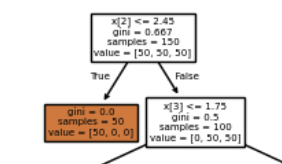

------

# Data 타이타닉 : 생사맞추기!!

In [ ]:
#라이브러리 import
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df = sns.load_dataset('titanic')

# 데이터 전처리
# 분석에 필요한 컬럼만 선택
features = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
df = df[features]

# 결측치(NaN) 처리
df['age'] = df['age'].fillna(df['age'].median())  # 나이는 중앙값으로 채움
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0]) # 항구는 최빈값으로 채움

# 범주형 데이터 숫자로 변환 (Encoding)
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['embarked'], drop_first=True) # One-hot Encoding

# 3. 학습/테스트 데이터 분리
X = df.drop('survived', axis=1) # 특성 (문제지)
y = df['survived']              # 타겟 (정답지)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2)

In [ ]:
# 4. AdaBoost 모델 정의 및 학습
# 기본 학습기(Base Estimator)는 보통 깊이가 1인 의사결정나무(Stump)를 사용
base_model = DecisionTreeClassifier(max_depth=1)

In [ ]:
# n_estimators: 약한 학습기(weak learner)의 개수
# learning_rate: 학습률 (가중치 갱신 강도)

# scikit-learn AdaBoost
ada_model= AdaBoostClassifier(estimator=base_model, n_estimators=100, learning_rate=1.0)

In [ ]:
ada_model.fit(X_train ,y_train )

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   n_estimators=100)

In [ ]:
# 5. 예측 및 평가

y_pred = ada_model.predict(X_test)

In [ ]:
acc = accuracy_score(y_test, y_pred)

In [ ]:
acc

0.7877094972067039